# Land use layer Prep

## Load LC layer

In [2]:
import rioxarray as rxr
from pathlib import Path

clc_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/LC_with_plantation")

# Load with xarray (has coordinates!)
dnk = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_dnk_{year}.tif") for year in [2018, 2021, 2023]}
nld = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_nld_{year}.tif") for year in [2018, 2021, 2023]}
uk = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_uk_{year}.tif") for year in [2018, 2023]}


In [ ]:
# import rioxarray as rxr
# from pathlib import Path

# clc_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/CLCplus")

# # Load with xarray (has coordinates!)
# dnk = {year: rxr.open_rasterio(clc_dir / f"clcplus_dnk_{year}.tif") for year in [2018, 2021, 2023]}
# nld = {year: rxr.open_rasterio(clc_dir / f"clcplus_nld_{year}.tif") for year in [2018, 2021, 2023]}
# uk = {year: rxr.open_rasterio(clc_dir / f"clcplus_uk_{year}.tif") for year in [2018, 2023]}


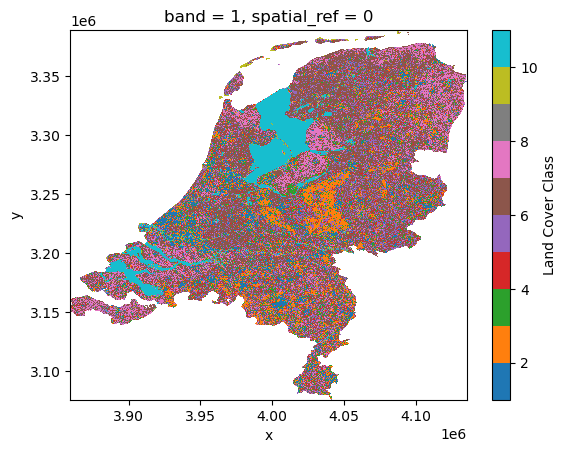

In [2]:

nld[2023].where((nld[2023] >= 1) & (nld[2023] <= 11)).coarsen(x=10, y=10, boundary="trim").mean().plot(
    cmap='tab10',
    vmin=1,
    vmax=11,
    cbar_kwargs={'label': 'Land Cover Class'}
)

## Fragmentation ECA(PC)

In [3]:
# ECA - Equivalent Connected Area
# Based on probability of connectivity

import numpy as np
from scipy import ndimage
from scipy.spatial.distance import cdist
import rioxarray as rxr

# Config
NATURAL_CLASSES = [2, 5]  # Adjust to your natural habitat classes
CELL_SIZE_M = 1000
PIXEL_SIZE_M = 10
DISPERSAL_DISTANCE = 500  # meters
cell_pixels = CELL_SIZE_M // PIXEL_SIZE_M

def calc_eca(lc_data, natural_classes, cell_pixels, dispersal_dist, pixel_size):
    """Calculate ECA in hectares"""
    # Binary natural habitat mask
    natural_mask = np.isin(lc_data, natural_classes).astype(np.uint8)
    
    # Grid dimensions
    rows = natural_mask.shape[0] // cell_pixels
    cols = natural_mask.shape[1] // cell_pixels
    eca_grid = np.zeros((rows, cols))
    
    for i in range(rows):
        for j in range(cols):
            cell = natural_mask[i*cell_pixels:(i+1)*cell_pixels,
                               j*cell_pixels:(j+1)*cell_pixels]
            
            # Label patches
            labeled, num = ndimage.label(cell)
            
            if num > 0:
                patch_sizes = np.bincount(labeled.ravel())[1:]
                patch_areas = patch_sizes * (pixel_size ** 2)
                total_area = patch_areas.sum()
                
                # Get centroids
                centroids = np.array([
                    ndimage.center_of_mass(labeled == pid) 
                    for pid in range(1, num + 1)
                ]) * pixel_size
                
                # Distances between patches
                distances = cdist(centroids, centroids) if num > 1 else np.array([[0]])
                
                # ECA calculation
                pc_sum = 0
                for p1 in range(num):
                    for p2 in range(num):
                        prob = 1.0 if p1 == p2 else np.exp(-distances[p1, p2] / dispersal_dist)
                        pc_sum += patch_areas[p1] * patch_areas[p2] * prob
                
                pc = pc_sum / (total_area ** 2)
                eca_grid[i, j] = np.sqrt(pc) * total_area / 10000  # to hectares
    
    return eca_grid

# Calculate ECA for all countries and years
eca_results = {}

for country_name, country_data in [('uk', uk), ('dnk', dnk), ('nld', nld)]:  # 
    eca_results[country_name] = {}
    
    for year in [2018, 2021, 2023]:
        if year not in country_data:
            print(f"Skipping {country_name.upper()} {year} (no data)")
            continue       
          
        print(f"Processing {country_name.upper()} {year}...")
        lc_array = country_data[year].values[0]  # Get numpy array from xarray
        
        eca_grid = calc_eca(lc_array, NATURAL_CLASSES, cell_pixels, 
                           DISPERSAL_DISTANCE, PIXEL_SIZE_M)
        
        eca_results[country_name][year] = eca_grid
        
        print(f"  Mean ECA: {eca_grid[eca_grid > 0].mean():.2f} ha")



Processing UK 2018...
  Mean ECA: 6.50 ha
Skipping UK 2021 (no data)
Processing UK 2023...
  Mean ECA: 6.30 ha
Processing DNK 2018...
  Mean ECA: 6.81 ha
Processing DNK 2021...
  Mean ECA: 6.60 ha
Processing DNK 2023...
  Mean ECA: 6.48 ha
Processing NLD 2018...
  Mean ECA: 5.86 ha
Processing NLD 2021...
  Mean ECA: 5.76 ha
Processing NLD 2023...
  Mean ECA: 5.62 ha


In [4]:
import rasterio
from rasterio.transform import from_origin

output_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/ECA2")
output_dir.mkdir(exist_ok=True, parents=True)

for country in ['uk','dnk', 'nld']: # 
    for year in [2018, 2021, 2023]:  # 
        if year not in eca_results[country]:
            continue
        # Get original transform and scale it
        original = eval(country)[year]  # Get xarray
        transform = original.rio.transform()
        scaled_transform = rasterio.Affine(
            transform.a * cell_pixels, transform.b, transform.c,
            transform.d, transform.e * cell_pixels, transform.f
        )
        
        # Save
        output_path = output_dir / f"eca_{country}_{year}.tif"
        with rasterio.open(output_path, 'w', driver='GTiff',
                          height=eca_results[country][year].shape[0],
                          width=eca_results[country][year].shape[1],
                          count=1, dtype='float32',
                          crs=original.rio.crs,
                          transform=scaled_transform,
                          compress='lzw') as dst:
            dst.write(eca_results[country][year], 1)
        
        print(f"Saved: {output_path}")

Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/ECA2/eca_uk_2018.tif
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/ECA2/eca_uk_2023.tif
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/ECA2/eca_dnk_2018.tif
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/ECA2/eca_dnk_2021.tif
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/ECA2/eca_dnk_2023.tif
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/ECA2/eca_nld_2018.tif
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/ECA2/eca_nld_2021.tif
Saved: /home/georg/data/LEON_P5_BII/EO_data_prep/ECA2/eca_nld_2023.tif


# Land cover

## Plantation
### Plantation = Woody - Natural Forest

In [ ]:
import numpy as np
from pathlib import Path
import rioxarray as rxr
from rasterio.enums import Resampling
import rasterio
from rasterio.transform import from_bounds
import gc

# ============== CHANGE THIS ==============
COUNTRY = 'uk'  # Options: 'dnk', 'nld', 'uk'
# =========================================

WOODY_CLASSES = [2, 3, 4]
NATURAL_THRESHOLD = 20

# Paths
lc_dir = Path("~/data/LEON_P5_BII/EO_data_prep/CLCplus").expanduser()
nat_dir = Path("~/data/LEON_P5_BII/EO_data_prep/Natural_forest_2020").expanduser()
output_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_plantation").expanduser()
output_dir.mkdir(exist_ok=True, parents=True)

YEARS = {
    'dnk': [2018, 2021, 2023],
    'nld': [2018, 2021, 2023],
    'uk': [2018, 2023]
}

print(f"\n{'='*60}")
print(f"PROCESSING: {COUNTRY.upper()}")
print(f"{'='*60}\n")

# Load natural forest once
nat_path = nat_dir / f"natural_forest_{COUNTRY}.tif"
print(f"Loading natural forest...")
nat_forest = rxr.open_rasterio(nat_path)

for year in YEARS[COUNTRY]:
    print(f"\n--- Year {year} ---")
    
    lc_path = lc_dir / f"clcplus_{COUNTRY}_{year}.tif"
    lc = rxr.open_rasterio(lc_path)
    
    # Resample
    print("  Resampling...")
    nat_resampled = nat_forest.rio.reproject_match(lc, resampling=Resampling.bilinear)
    
    # Classify IN-PLACE (no copy)
    print("  Classifying...")
    lc_arr = lc.values[0]
    nat_arr = nat_resampled.values[0]
    
    is_woody = np.isin(lc_arr, WOODY_CLASSES)
    is_plantation = is_woody & (nat_arr < NATURAL_THRESHOLD)
    is_natural = is_woody & (nat_arr >= NATURAL_THRESHOLD)
    
    print(f"    Natural: {is_natural.sum():,} | Plantation: {is_plantation.sum():,}")
    
    # Modify IN-PLACE
    lc_arr[is_natural] = 2
    lc_arr[is_plantation] = 3
    
    # Save using rasterio directly (more efficient)
    print("  Saving...")
    output_path = output_dir / f"lc_forest_{NATURAL_THRESHOLD}_{COUNTRY}_{year}.tif"
    
    with rasterio.open(
        output_path, 'w',
        driver='GTiff',
        height=lc_arr.shape[0],
        width=lc_arr.shape[1],
        count=1,
        dtype=lc_arr.dtype,
        crs=lc.rio.crs,
        transform=lc.rio.transform(),
        compress='LZW'
    ) as dst:
        dst.write(lc_arr, 1)
    
    print(f"  ✓ {output_path.name}")
    
    # Aggressive cleanup
    del lc, nat_resampled, lc_arr, nat_arr, is_woody, is_plantation, is_natural
    gc.collect()

del nat_forest
gc.collect()

print(f"\n✅ {COUNTRY.upper()} COMPLETE!")


PROCESSING: UK

Loading natural forest...

--- Year 2018 ---
  Resampling...
  Classifying...
    Natural: 51,238,167 | Plantation: 90,412,179
  Saving...
  ✓ lc_forest_20_uk_2018.tif

--- Year 2023 ---
  Resampling...
  Classifying...
    Natural: 49,891,189 | Plantation: 84,871,658
  Saving...
  ✓ lc_forest_20_uk_2023.tif

✅ UK COMPLETE!


In [ ]:
from pathlib import Path

output_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/Forest_classification")
output_dir.mkdir(exist_ok=True, parents=True)

# DNK
for year in [2018, 2021, 2023]:
    classification = classify_forest(dnk[year].values[0], dnk_nat_forest.values[0], WOODY_CLASSES, NATURAL_THRESHOLD)
    template = dnk[year].copy()
    template.values[0] = classification
    template.rio.to_raster(output_dir / f"forest_dnk_{year}.tif", compress='LZW')
    print(f"✓ forest_dnk_{year}.tif")

# NLD
for year in [2018, 2021, 2023]:
    classification = classify_forest(nld[year].values[0], nld_nat_forest.values[0], WOODY_CLASSES, NATURAL_THRESHOLD)
    template = nld[year].copy()
    template.values[0] = classification
    template.rio.to_raster(output_dir / f"forest_nld_{year}.tif", compress='LZW')
    print(f"✓ forest_nld_{year}.tif")

# UK
for year in [2018, 2023]:
    classification = classify_forest(uk[year].values[0], uk_nat_forest.values[0], WOODY_CLASSES, NATURAL_THRESHOLD)
    template = uk[year].copy()
    template.values[0] = classification
    template.rio.to_raster(output_dir / f"forest_uk_{year}.tif", compress='LZW')
    print(f"✓ forest_uk_{year}.tif")

print("\nAll saved!")

## Secondary Vegetation Categorisation

In [1]:
import rioxarray as rxr
from pathlib import Path

clc_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/LC_with_plantation")
td_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/Tree_Density")

# Xarray
# Land cover + Plantation
lc_dnk = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_dnk_{year}.tif") for year in [2018, 2021, 2023]}
lc_nld = {year: rxr.open_rasterio(clc_dir / f"lc_forest_20_nld_{year}.tif") for year in [2018, 2021, 2023]}

# Tree Density (note: files have _merged suffix)
td_dnk = {year: rxr.open_rasterio(td_dir / f"tree_cover_density_dnk_{year}_merged.tif") for year in [2018, 2021, 2023]}
td_nld = {year: rxr.open_rasterio(td_dir / f"tree_cover_density_nld_{year}_merged.tif") for year in [2018, 2021, 2023]}

In [2]:
import rioxarray as rxr
import numpy as np
import rasterio
from pathlib import Path
import gc

# Setup - expand ~ to full path
lc_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_plantation").expanduser()
td_dir = Path("~/data/LEON_P5_BII/EO_data_prep/Tree_Density").expanduser()
output_dir = Path("~/data/LEON_P5_BII/EO_data_prep/LC_with_secondary_veg").expanduser()
output_dir.mkdir(parents=True, exist_ok=True)

YEARS = [2018, 2021, 2023]
COUNTRIES = ['dnk', 'nld']

# Process each country
for country in COUNTRIES:
    print(f"\n{country.upper()}")
    
    for year in YEARS:
        print(f"  {year}...")
        
        # Load data
        lc = rxr.open_rasterio(lc_dir / f"lc_forest_20_{country}_{year}.tif")
        td = rxr.open_rasterio(td_dir / f"tree_cover_density_{country}_{year}_merged.tif")
        
        # Resample tree density to match land cover
        td = td.rio.reproject_match(lc, resampling=rasterio.enums.Resampling.bilinear)
        
        # Get arrays
        lc_arr = lc.values.squeeze()
        td_arr = td.values.squeeze()
        output = lc_arr.copy()
        
        # Reclassify Natural Forest (class 2) by tree density
        is_natural = (lc_arr == 2)
        output[is_natural & (td_arr > 90) & (td_arr <= 100)] = 21                          # SV Mature
        output[is_natural & (td_arr >= 70) & (td_arr <= 90)] = 22       # SV Intermediate
        output[is_natural & (td_arr < 70)] = 23                          # SV Young
        output[lc_arr == 5] = 24                                         # SV Indeterminate
        
        # Save
        output_path = output_dir / f"lc_sv_{country}_{year}.tif"
        with rasterio.open(
            output_path, 'w',
            driver='GTiff',
            height=output.shape[0],
            width=output.shape[1],
            count=1,
            dtype=output.dtype,
            crs=lc.rio.crs,
            transform=lc.rio.transform(),
            compress='LZW'
        ) as dst:
            dst.write(output, 1)
        
        # Cleanup
        del lc, td, lc_arr, td_arr, output
        gc.collect()

print("\n✅ Done!")


DNK
  2018...
  2021...
  2023...

NLD
  2018...
  2021...
  2023...

✅ Done!


## Bare total

In [1]:
import rasterio
import numpy as np
from pathlib import Path

bare_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/Bare")
output_dir = Path("/home/georg/data/LEON_P5_BII/EO_data_prep/Bare_Total")
output_dir.mkdir(exist_ok=True)

countries = ['dnk', 'nld']
years = [2018, 2021, 2023]
MAX_VALUE = 370

for country in countries:
    for year in years:
        print(f"Processing {country.upper()} {year}...")
        
        before_path = bare_dir / f"bare_before_{country}_{year}_clip.tif"
        after_path = bare_dir / f"bare_after_{country}_{year}_clip.tif"
        output_path = output_dir / f"bare_total_{country}_{year}.tif"
        
        with rasterio.open(before_path) as before_src, \
             rasterio.open(after_path) as after_src:
            
            profile = before_src.profile.copy()
            profile.update(compress='LZW')
            
            # Process in chunks
            with rasterio.open(output_path, 'w', **profile) as dst:
                for ji, window in before_src.block_windows(1):
                    before_data = before_src.read(1, window=window).astype(float)
                    after_data = after_src.read(1, window=window).astype(float)
                    
                    # Filter > 370 BEFORE adding
                    before_data[before_data > MAX_VALUE] = np.nan
                    after_data[after_data > MAX_VALUE] = np.nan
                    
                    # Add (np.nan propagates correctly)
                    total_data = before_data + after_data
                    
                    dst.write(total_data.astype(profile['dtype']), 1, window=window)
        
        print(f"  ✓ Saved: {output_path.name}")

print("\nDone!")

Processing DNK 2018...


/tmp/ipykernel_486736/802773832.py:40: RuntimeWarning: invalid value encountered in cast
  dst.write(total_data.astype(profile['dtype']), 1, window=window)


  ✓ Saved: bare_total_dnk_2018.tif
Processing DNK 2021...
  ✓ Saved: bare_total_dnk_2021.tif
Processing DNK 2023...
  ✓ Saved: bare_total_dnk_2023.tif
Processing NLD 2018...
  ✓ Saved: bare_total_nld_2018.tif
Processing NLD 2021...
  ✓ Saved: bare_total_nld_2021.tif
Processing NLD 2023...
  ✓ Saved: bare_total_nld_2023.tif

Done!


In [ ]:
## Load total bare data
dnk_bare = {
    2018: rxr.open_rasterio(output_dir / "bare_total_dnk_2018.tif"),
    2021: rxr.open_rasterio(output_dir / "bare_total_dnk_2021.tif"),
    2023: rxr.open_rasterio(output_dir / "bare_total_dnk_2023.tif")
}

nld_bare = {
    2018: rxr.open_rasterio(output_dir / "bare_total_nld_2018.tif"),
    2021: rxr.open_rasterio(output_dir / "bare_total_nld_2021.tif"),
    2023: rxr.open_rasterio(output_dir / "bare_total_nld_2023.tif")
}

print("Loaded!")